In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
especies = pd.read_csv("especies_202510091201.csv", usecols=["especie_id", "nome_vernaculo"])

registros = pd.read_csv("especializacao_pedro_tashima_registros_aves_202510091518.csv")


In [3]:
df = pd.merge(especies, registros, on="especie_id")
df.to_csv("registros_atualizado.csv")

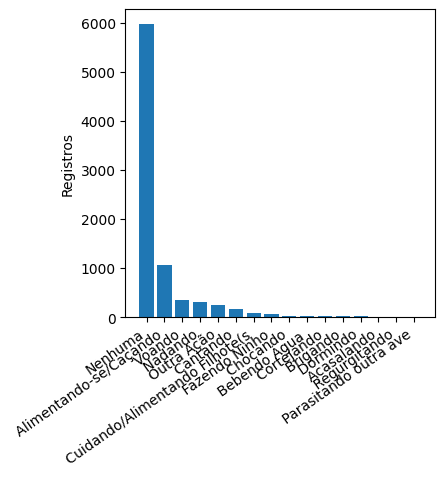

In [82]:
acoes = pd.read_csv("./acoes.csv")

plt.figure(figsize=(4, 4))


plt.ylabel('Registros')
plt.bar(acoes["acao"], acoes['total'], label='Registros')
plt.xticks(rotation=35, fontsize=10, ha='right')

plt.savefig("acoes.eps", format='eps', bbox_inches='tight', pad_inches=0.1)

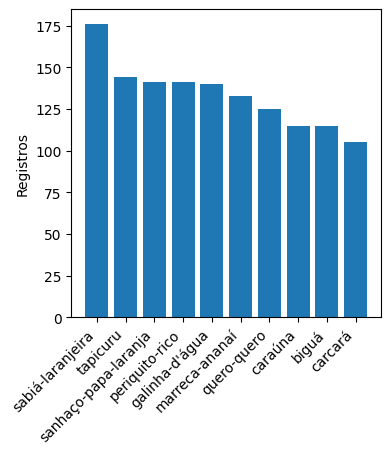

In [83]:
top_especies = pd.read_csv("./top-10-especies.csv")

plt.figure(figsize=(4, 4))
plt.ylabel('Registros')

plt.bar(top_especies["nome_vernaculo"], top_especies['total'], label='Registros')
plt.xticks(rotation=45, ha='right')

plt.savefig("top-10-especies.eps", format='eps', bbox_inches='tight', pad_inches=0.1)


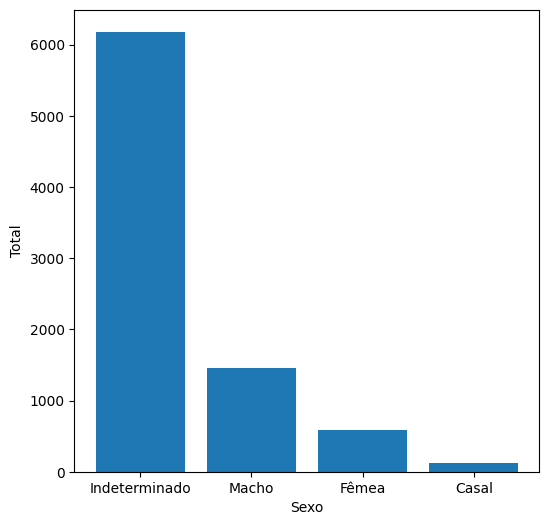

In [6]:
sexos = pd.read_csv("./sexos.csv")

plt.figure(figsize=(6, 6))
plt.ylabel('Total')
plt.xlabel('Sexo')
plt.bar(sexos["sexo"], sexos['total'], label='Ocorrencias')
#plt.xticks(rotation=35, ha='right')

plt.savefig("sexos.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)


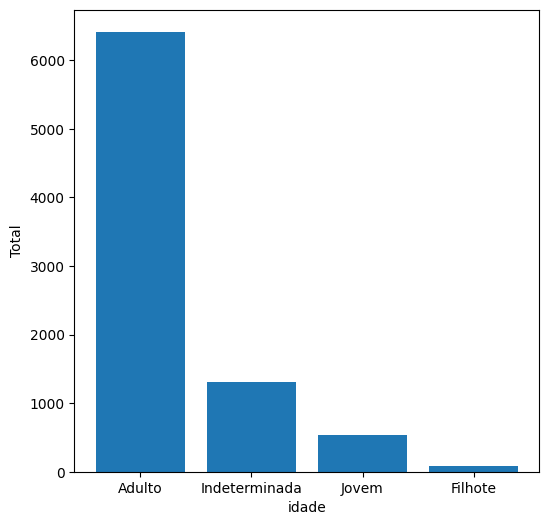

In [7]:
idades = pd.read_csv("./idades.csv")

plt.figure(figsize=(6, 6))
plt.ylabel('Total')
plt.xlabel('idade')
plt.bar(idades["idade"], idades['total'], label='Ocorrencias')

plt.savefig("idades.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)


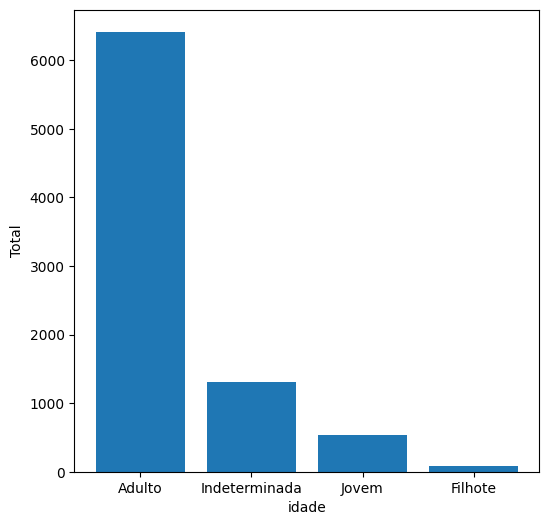

In [ ]:
idades = pd.read_csv("./idades.csv")

plt.figure(figsize=(6, 6))
plt.ylabel('Total')
plt.xlabel('idade')
plt.bar(idades["idade"], idades['total'], label='Ocorrencias')

plt.savefig("idades.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)


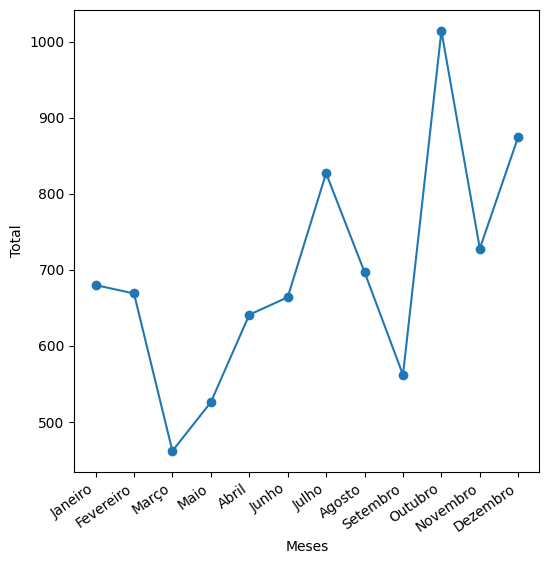

In [8]:
meses = pd.read_csv("./meses.csv")
meses['ano'] = meses['mes'].astype(str)

plt.figure(figsize=(6, 6))
plt.ylabel('Total')
plt.xlabel('Meses')
plt.plot(meses["mes"], meses['total'], label='Ocorrencias', marker='o', linestyle='-')
plt.xticks(rotation=35, ha='right')

plt.savefig("meses.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


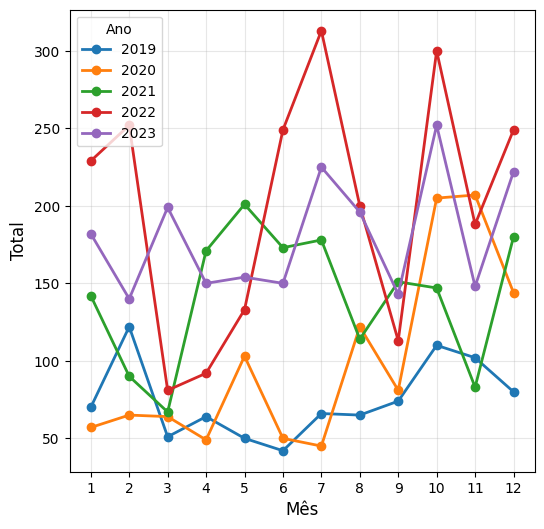

In [9]:
df = pd.read_csv("mes_ano.csv")
pivot_df = df.pivot(index='mes', columns='ano', values='total')
pivot_df = pivot_df.sort_index()          # ensure months are 1..12
pivot_df

plt.figure(figsize=(6, 6))

# Define a colour cycle (optional – you can rely on Matplotlib defaults)
colors = plt.cm.tab10.colors   # 10 distinct colours; we only need 5

for i, year in enumerate(pivot_df.columns):
    plt.plot(
        pivot_df.index,                 # months on the x‑axis
        pivot_df[year],                 # totals for this year on the y‑axis
        marker='o',
        linewidth=2,
        color=colors[i % len(colors)],
        label=str(year)                 # legend entry
    )

plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total', fontsize=12)

# Make month ticks look nice (1‑12)
plt.xticks(ticks=range(1, 13))
plt.grid(alpha=0.3)                     # light gray grid

plt.legend(title='Ano', loc='upper left')

plt.savefig("mes_ano.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


              local_nome  total   area_agua         area      ratio
0         Parque Barigui   1004  227.030424  1349.174974  16.827352
1          Parque Iguaçu    520  522.367684  6890.014039   7.581518
2          Parque Tanguá    200   24.886778   225.069579  11.057371
3              Zoológico    164   61.416719   735.037180   8.355594
4        Jardim Botânico    164    9.696444   198.991860   4.872784
5        Parque Passaúna    129   14.884879   600.462175   2.478904
6  Parque da Barreirinha     89    5.873233   132.293106   4.439561
7    Parque do Bacacheri     85   25.124645   164.406239  15.282051
8    Parque São Lourenço     71   43.445078   229.852027  18.901325
9          Parque Tingui     69   80.970129   402.725557  20.105535


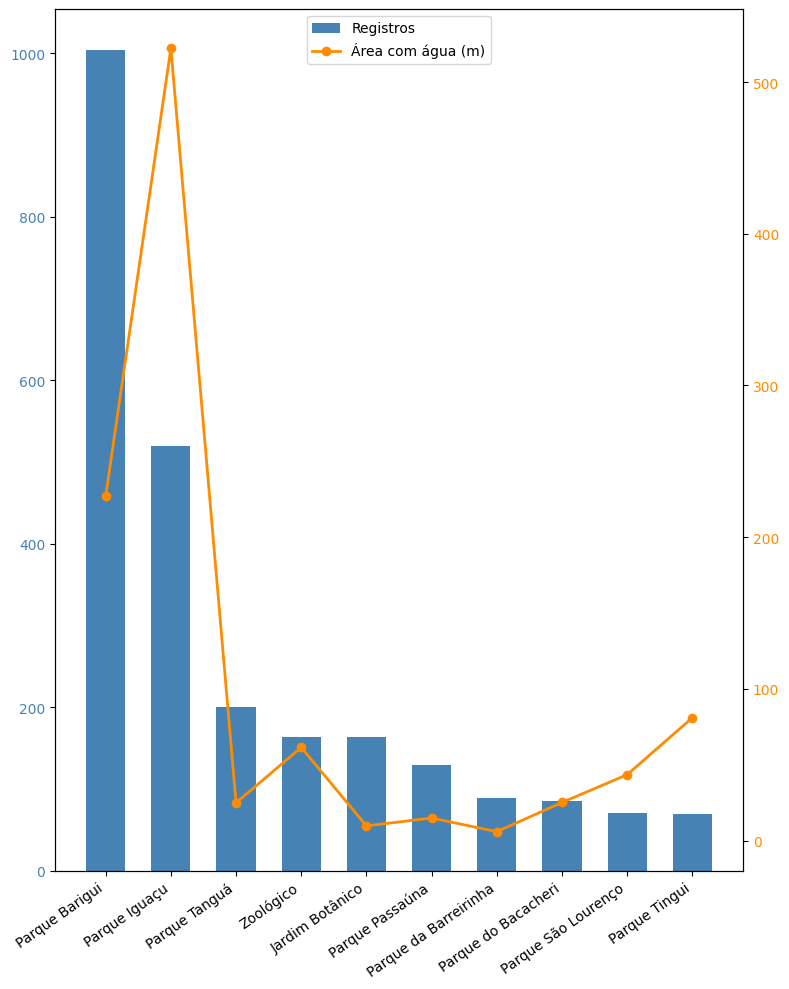

In [78]:
df = pd.read_csv("locais_rios_total.csv")

df["area"] = df["area"] / 1000
df["area_agua"] = df["area_agua"] / 1000

df["ratio"] = (df["area_agua"] / df["area"]) * 100

df.sort_values("ratio", ascending=True)

df = df.head(10)
print(df)

fig, ax1 = plt.subplots(figsize=(8, 10))

bars = ax1.bar(df['local_nome'], df['total'],
               color='steelblue', label='Registros', width=0.6)

for label in ax1.get_xticklabels():
    label.set_rotation(35)          # tilt the text
    label.set_ha('right')           # horizontal‑alignment = right

# ax1.set_ylabel('Registros', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# 2️⃣  Secondary axis for the line
ax2 = ax1.twinx()                     # creates a second y‑axis sharing x
line = ax2.plot(df['local_nome'], df['area_agua'],
                color='darkorange', marker='o',
                linewidth=2, label='Área com água (m)')

# ax2.set_ylabel('Proporção de área com água', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')


# # 3️⃣  Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper center")


plt.tight_layout()
plt.savefig("registros_area_agua.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)
plt.show()

In [76]:
df[["area", "area_agua", "total", "ratio"]].corr(method="pearson")

,area,area_agua,total,ratio
area,1.000000,0.964255,0.462542,-0.155168
area_agua,0.964255,1.000000,0.640053,0.037513
total,0.462542,0.640053,1.000000,0.148577
ratio,-0.155168,0.037513,0.148577,1.000000


In [30]:

df = pd.read_csv("locais_rios_total.csv")

df["area"] = df["area"] / 1000
df["area_agua"] = df["area_agua"] / 1000

df["ratio"] = df["area_agua"] / df["area"]

df.sort_values("ratio", ascending=False)

,local_nome,total,area_agua,area,ratio
0,Parque Barigui,1004,221.768395,603.920992,3.672143e-01
11,Parque Passeio Público,48,14.567879,65.283263,2.231488e-01
9,Parque Tingui,69,67.612225,336.325299,2.010322e-01
8,Parque São Lourenço,71,43.445078,229.852027,1.890132e-01
7,Parque do Bacacheri,85,25.124645,164.406239,1.528205e-01
2,Parque Tanguá,200,24.886778,220.043526,1.130993e-01
4,Zoológico,164,61.416719,735.037180,8.355594e-02
16,Bosque Irmã Clementina,9,1.597177,21.156524,7.549335e-02
13,Parque do Atuba,25,9.701002,132.039818,7.347028e-02
3,Jardim Botânico de Curitiba,164,9.696444,198.991860,4.872784e-02


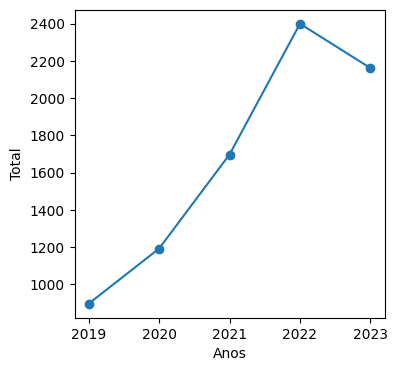

In [10]:
anos = pd.read_csv("./anos.csv")
anos['ano'] = anos['ano'].astype(str)

plt.figure(figsize=(4, 4))
plt.ylabel('Total')
plt.xlabel('Anos')
plt.plot(anos["ano"], anos['total'], label='Ocorrencias', marker='o', linestyle='-')

plt.savefig("anos.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)

In [11]:
!pip install folium

In [12]:
df = pd.read_csv("./locais.csv")

import numpy as np

def radius_from_total(total, factor=50):
    return np.sqrt(total) * factor

import folium

# Compute the geographic centre
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=12,            # adjust zoom as needed
               tiles='CartoDB positron')   # clean, light basemap

for _, row in df.iterrows():
    folium.Circle(
        location=[row['latitude'], row['longitude']],
        radius=radius_from_total(row['total']),      # radius in meters (Folium expects metres)
        color='steelblue',
        fill=True,
        fill_color='steelblue',
        fill_opacity=0.4,
        popup=folium.Popup(f"<b>{row['local_nome']}</b><br>Total: {row['total']}",
                           max_width=250)
    ).add_to(m)

m
    

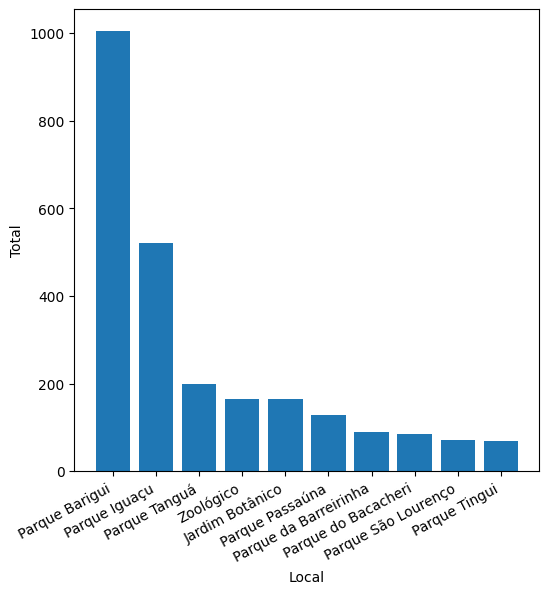

In [13]:
plt.figure(figsize=(6, 6))
plt.ylabel('Total')
plt.xlabel('Local')
plt.bar(df["local_nome"], df['total'], label='Ocorrencias')
plt.xticks(rotation=28, ha='right')

plt.savefig("locais.eps", format='eps' , bbox_inches='tight', pad_inches=0.1)

In [34]:
import json

with open("./parques-geos.json") as fp:
    geo_json_data = json.load(fp)

m = folium.Map([-25.43289, -49.27111], zoom_start=13)

folium.GeoJson(
    geo_json_data,
).add_to(m)

folium.LayerControl().add_to(m)

m